In [3]:
import numpy as np
import pandas as pd
from google.colab import drive
import os
import matplotlib.pyplot as plt

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
drive.mount('/content/drive', force_remount=True)
os.chdir('/content/drive/MyDrive/Neurociencia Cognitiva/TP FINAL/ARCHIVOS')

Mounted at /content/drive


In [6]:
cant_archivos = int(len(os.listdir('/content/drive/MyDrive/Neurociencia Cognitiva/TP FINAL/ARCHIVOS'))/3)+1
print(cant_archivos)

posicion =[]
respuesta = []
tiempo = []

for i in range(1, cant_archivos):
    nombre_archivo = f'data13_{i}.csv'  #cambie el nombre
    df = pd.read_csv(nombre_archivo)

    posicion = list(posicion) + list(df.iloc[:, 2])
    respuesta = list(respuesta) + list(df.iloc[:, 3])#armo listas que contienen TODAS las respuestas de todos los archivos
    tiempo = list(tiempo) + list(df.iloc[:, 4])

print(len(respuesta), len(respuesta), len(tiempo))

rtas_corr = np.array([0]*13) #vector de cantidad de rtas correctas

for j in range(len(respuesta)):
        if  respuesta[j] == 1:            #miro solo las respuestas correctas
            rtas_corr[posicion[j]-1] += 1 #al vector de rtas correctas le sumo uno en la posicion de la letra
print(rtas_corr)

24
805 805 805
[21 19 22 22 19 28 25 25 25 33 37 37 41]


In [7]:
posiciones_suma = np.array([0]*13)
desvest_sumaal2 = np.array([0]*13)

for i in range(1, cant_archivos):
    nombre_archivo = f'data13_{i}.csv'
    df = pd.read_csv(nombre_archivo)

    posicion_i = list(df.iloc[:, 2])
    respuesta_i = list(df.iloc[:, 3])

    rtas_corr_i = np.array([0]*13) #en cada archivo cada vez que cambie de i vuelve a hacer la lista
    for j in range(35):
        if  respuesta_i[j] == 1:
            rtas_corr_i[posicion_i[j]-1] += 1
    print(rtas_corr_i)

    #dsp del ultimo paso ya tengo el array rtas_corr_i que tiene la cantidad de rtas correctas por posicion del archivo i.
    promedio_i = (rtas_corr_i/2) #CAMBIE EL 3 POR UN 2
    #print(promedio_i)
    posiciones_suma = posiciones_suma + promedio_i #despues voy a promediar los promedios de todos los archivos y pasarlo a porcentaje entonces aca los voy sumando y a lo ultimo voy a dividir por cant_archivos

    devest_i = [] #ahora voy a sacar las desvest por pos de cada archivo i
    for k in range(len(rtas_corr_i)):
        if rtas_corr_i[k] == 0 or rtas_corr_i[k] == 2:
            devest_i.append(0)
        else:
            devest_i.append(0.5)
    #print(devest_i)
    desvest_sumaal2 = desvest_sumaal2 + np.array(devest_i)**2
    #print(desvest_sumaal2)

#ya afuera de todos los loops termino de calcular el prom y los errores

#print(posiciones_suma)
porcentajes_prom = (posiciones_suma/cant_archivos)*100
print(porcentajes_prom)

desvest_prom = (np.sqrt(desvest_sumaal2)/cant_archivos)*100
print(desvest_prom)

[0 1 2 1 1 2 1 1 1 2 2 2 2]
[2 2 1 2 2 2 2 1 1 2 2 2 2]
[2 1 2 2 1 2 1 1 1 1 2 1 1]
[0 1 2 2 0 1 1 1 2 2 1 2 2]
[2 1 1 2 0 1 1 2 0 0 2 2 2]
[1 1 1 1 1 1 1 2 0 2 0 1 2]
[2 0 1 1 1 2 2 2 2 2 2 2 2]
[0 0 1 0 1 0 1 2 2 2 2 2 2]
[0 1 1 0 1 0 1 1 1 2 2 2 2]
[1 2 1 1 0 1 0 1 0 1 1 1 2]
[0 1 1 1 1 1 0 1 1 1 1 0 2]
[0 1 2 0 1 2 2 2 1 2 2 1 2]
[1 1 2 2 1 1 1 1 2 2 2 2 2]
[1 1 0 2 2 2 2 2 1 2 2 2 2]
[2 0 1 1 1 2 2 0 1 2 2 2 2]
[2 1 1 1 1 2 0 1 1 2 2 2 2]
[1 0 1 1 1 0 2 1 1 1 1 2 2]
[0 1 1 0 1 2 0 1 1 1 1 2 2]
[1 0 0 1 0 2 1 1 1 0 2 1 1]
[1 1 0 0 0 0 1 0 1 1 1 1 0]
[0 1 0 0 0 1 0 1 2 2 2 1 2]
[1 1 0 1 2 1 2 0 2 1 2 2 2]
[1 0 0 0 0 0 1 0 0 0 1 2 1]
[43.75       39.58333333 45.83333333 45.83333333 39.58333333 58.33333333
 52.08333333 52.08333333 52.08333333 68.75       77.08333333 77.08333333
 85.41666667]
[6.25       8.0687153  7.21687836 6.58807846 7.51156516 5.89255651
 6.90963498 7.51156516 7.51156516 5.5119819  5.5119819  5.5119819
 3.60843918]


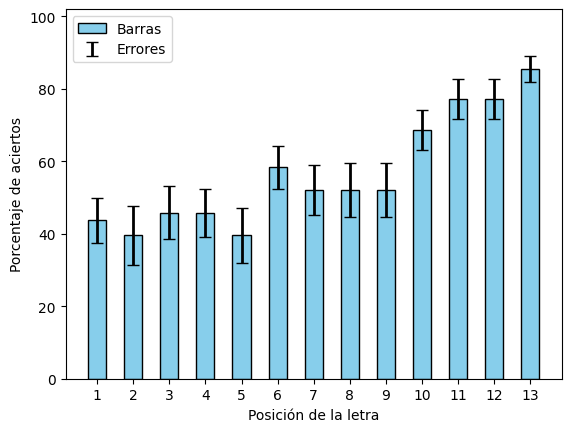

In [11]:
#ploteo
x = np.array(range(1,14))

plt.bar(x, porcentajes_prom, width = 0.5, color='skyblue', edgecolor='black', label='Barras') #gráfico de barras
plt.errorbar(x, porcentajes_prom, yerr=desvest_prom, fmt='none', ecolor='black', elinewidth=2, capsize=4, label='Errores')
plt.legend()
plt.xlabel('Posición de la letra')
plt.ylabel('Porcentaje de aciertos')
plt.ylim(0,102)
plt.xticks(range(1, 14))
#plt.title('Respuestas correctas por posición')
plt.show()


In [9]:
prom3_1, prom3_2, prom3_3, prom3_4, prom3_5, prom3_6, prom3_7, prom3_8, prom3_9, prom3_10, prom3_11, prom3_12, prom3_13 = [],[],[],[],[],[],[],[],[],[],[],[],[] #promedio de las 3 rtas en cada posicion. prom3_k
dsv3_1, dsv3_2, dsv3_3, dsv3_4, dsv3_5, dsv3_6, dsv3_7, dsv3_8, dsv3_9, dsv3_10, dsv3_11, dsv3_12, dsv3_13 = [],[],[],[],[],[],[],[],[],[],[],[],[] #dsv3_k

for i in range(1, cant_archivos): #leo cada archivo y nombro sus columnas
    nombre_archivo = f'data13_{i}.csv'
    df = pd.read_csv(nombre_archivo)
    posicion_i = list(df.iloc[:, 2])
    respuesta_i = list(df.iloc[:, 3])
    tiempo_i = list(df.iloc[:, 4])

    tiempo_en0_i = [] #normalizo los tiempos
    promedio_i = np.mean(tiempo_i)
    desvest_i = np.std(tiempo_i)
    for j in range(35):
        tiempo_en0_i.append((tiempo_i[j]-promedio_i)/desvest_i) #appendeo de una los 35 tiempos normalizados del archivo i


    for k in range (1, 13+1):
        t3_i_k = [] #lista para+ los 3 tiempos de las rtas por pos. Se vuelve a hacer cada que cambia k (CAMBIA A 2)
        t3_i_k.clear()
        for j in range(35):
            if posicion_i[j] == k:
                if respuesta_i[j] == 1: #cuando responden bien appendeo el tiempo correspondiente a la lista tik
                    t3_i_k.append(tiempo_en0_i[j])

        if len(t3_i_k) == 0:         #ARREGLADO: queda mal cuando no contestaron bien ninguna de las tres, tik queda vacio
            eval(f"prom3_{k}").append(0)
            eval(f"dsv3_{k}").append(0)
        else:
            eval(f"prom3_{k}").append(np.mean(t3_i_k)) #en prom_k guardo el promedio de las 3 rtas por posicion
            eval(f"dsv3_{k}").append(np.std(t3_i_k)/len(t3_i_k)) #guardo el errores de estos promedios

        #print("Datos contienen NaNs:", np.any(np.isnan(prom3_1)))

#hasta aca hice el primedio por persona/archivo del tiempo en cada una delas 13 posiciones.
#queda promediar los tiempos de todos los archivos, por posicion

prom_t_tot = []
err_t_tot = []

for k in range (1, 13+1):
    prom_t_tot.append(np.mean(eval(f"prom3_{k}"))) #hago el promedio de los promedios en cada posicion k
    dsv_array = np.array(eval(f"dsv3_{k}")) #paso a array las dsv
    err_t_tot.append(np.sqrt(sum(dsv_array**2))/cant_archivos) #el error del prom

print(prom_t_tot)
print(err_t_tot)

[0.16341858779568308, 0.21400788245241673, 0.10136097065049862, -0.09385664640416118, 0.05750332800954593, -0.19329706205510658, 0.04280852626054644, 0.33776283358582077, -0.11699586858419991, 0.028998148285579017, -0.3521142164620219, -0.34425978362239357, -0.6340479051992645]
[0.035749111005979974, 0.006105952140763486, 0.017131363204982007, 0.026747477414154956, 0.02174119298542912, 0.03130624714637497, 0.02155600461645099, 0.021782355005830024, 0.04604512653210849, 0.06640225943102679, 0.04114055708536484, 0.04874843455945991, 0.03357354864996627]


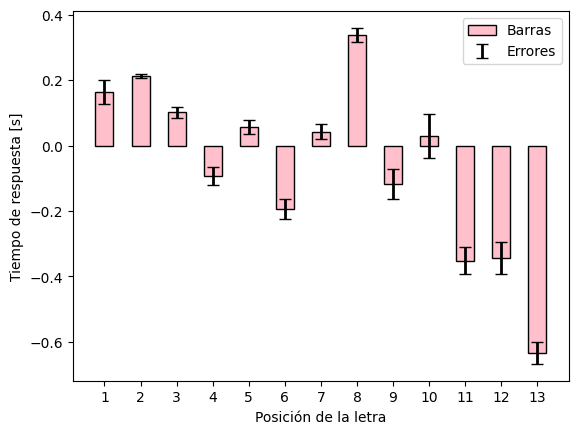

In [12]:
#ploteo
plt.bar(x, prom_t_tot, width = 0.5, color='pink', edgecolor='black', label='Barras') #gráfico derrorbare barras
plt.xlabel('Posición de la letra')
plt.ylabel('Tiempo de respuesta [s]')
plt.errorbar(x, prom_t_tot, yerr=err_t_tot, fmt='none', ecolor='black', elinewidth=2, capsize=4, label='Errores')
plt.legend()
plt.xticks(range(1, 14))
#plt.title('Tiempos de respuesta por posición')
plt.show()